# Model Training 

Model Training Part of the Project

Based on the complexity and high-dimensionality of the data, the following models are chosen:
- XGBoost
- Random Forest
- Neural Network

These models were chosen because they don't have some strict assumptions to get a meaningful result,
can capture underlying patterns very well. Furthermore, might apply Principal Component Analysis, Cross-Validation, & Hyper-parameter tuning to the model, probably using optuna

### General Functions

Add a common ingest data function that reads splits, and returns X_train, y_train & X_test, y_test cols

## XGBoost

In [ ]:
import pandas as pd

#Load pre-split data
train_df = pd.read_parquet("../data/splits/train.parquet")
test_df = pd.read_parquet("../data/splits/test.parquet")

#Separate features and target
X_train, y_train = train_df.drop(columns=["rating"]), train_df["rating"]
X_test, y_test = test_df.drop(columns=["rating"]), test_df["rating"]


In [ ]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from xgboost.callback import EarlyStopping
import numpy as np
import optuna

def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        
        # Required parameters for xgb.train
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "auto"
    }
    
    # Separate parameter for num_boost_round
    num_boost_round = trial.suggest_int("n_estimators", 200, 2000)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, valid_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]
        
        D_train = xgb.DMatrix(X_tr, y_tr)
        D_valid = xgb.DMatrix(X_val, y_val)
        
        model = xgb.train(
            params=params,
            dtrain=D_train,
            num_boost_round=num_boost_round,
            evals=[(D_train, "Train"), (D_valid, "Valid")],
            callbacks=[EarlyStopping(rounds=50, metric_name='rmse', data_name='Valid')],
            verbose_eval=False
        )

        preds = model.predict(D_valid)
        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)
        
        # Report progress to Optuna
        trial.report(rmse, len(rmse_scores) - 1)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(rmse_scores)

In [ ]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)


print("Best RMSE(CV):", study.best_value)
print("Best hyperparameters:", study.best_params)


# Train the best model on the full training set
best_params = study.best_trial.params
num_boost_round = best_params.pop('n_estimators')
best_params.update({
    "objective":"reg:squarederror",
    "eval_metric":"rmse",
    "tree_method":"auto"
})
D_full_train = xgb.DMatrix(X_train,y_train)

best_model = xgb.train(
    params = best_params,
    dtrain=D_full_train,
    num_boost_round=num_boost_round,
)
#Predicting on the test set
D_test = xgb.DMatrix(X_test)
test_preds = best_model.predict(D_test)

rmse = root_mean_squared_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print(f"Test Metrics RMSE: {rmse}  | R(squared): {r2}")


### Diagnostic Plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

residuals = y_test - test_preds


plt.figure(figsize=(10,8))
plt.scatter(test_preds, residuals, alpha=.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residuals vs Predicted Values")
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test)

### SHAP Value Plot

- This plot provides the global explanation of the XGBoost model, by showing the features that contribute the most to the model.

#### Feature Importance
- Members
- Popularity
- Studios_Target_enc

These are the top 3 important predictors in the models output.

#### SHAP values impact
- Postive SHAP value → feature increases the model output
- Negative SHAP value → feature decreases the models output

#### Colors
- Red dots = high feature value
- Blue dots = low feature value

#### Direction
- If red dots are on the right → higher feature increases prediction
- If red dots are on the left → higher feature lowers prediction


## Random Forest

In [1]:
import pandas as pd

#Load pre-split data
train_df = pd.read_parquet("../data/splits/train.parquet")
test_df = pd.read_parquet("../data/splits/test.parquet")

#Separate features and target
X_train, y_train = train_df.drop(columns=["rating"]), train_df["rating"]
X_test, y_test = test_df.drop(columns=["rating"]), test_df["rating"]


In [2]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import KFold
import numpy as np

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 2000),
        'max_features':trial.suggest_float('max_features', 0.3,0.8),
        'max_depth':trial.suggest_int('max_depth',5,51),
        'min_samples_split':trial.suggest_int('min_samples_split', 2,20), # Controls when the tree is allowed to split, higher val = fewer splits (simple trees),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 10), # Ensures each leaf has enough samples, higher value (smoother predictions, less overfitting)
        'criterion':'squared_error'
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = RandomForestRegressor(
            **params,
        )
        model.fit(X_tr, y_tr)
        
        preds = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)
        
        #Report progress to Optuna
        trial.report(rmse, len(rmse_scores) - 1)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return np.mean(rmse_scores)

/opt/homebrew/Caskroom/miniconda/base/envs/COP4283_Project/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25)

print(f"Best hyperparameters:{study.best_params}")
print(f"Best value: {study.best_value}")


best_rf_model = RandomForestRegressor(
    **study.best_params,
)

best_rf_model.fit(X_train, y_train)
y_pred = best_rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Test Metrics RMSE: {rmse}  | R(squared): {r2_score(y_test, y_pred)}")

[I 2025-11-29 16:25:49,580] A new study created in memory with name: no-name-176fae2e-6b5b-41f6-80cb-b673d1dd7410
[I 2025-11-29 16:27:27,300] Trial 0 finished with value: 0.5030915846097097 and parameters: {'n_estimators': 1018, 'max_features': 0.6143751832669033, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.5030915846097097.
[I 2025-11-29 16:30:49,328] Trial 1 finished with value: 0.45902953605083213 and parameters: {'n_estimators': 1614, 'max_features': 0.5688350118442212, 'max_depth': 26, 'min_samples_split': 16, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.45902953605083213.
[I 2025-11-29 16:34:21,088] Trial 2 finished with value: 0.47266090021431967 and parameters: {'n_estimators': 1810, 'max_features': 0.61704279140547, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.45902953605083213.
[I 2025-11-29 16:37:53,157] Trial 3 finished with value: 0.46946016323549145 and parameters

Best hyperparameters:{'n_estimators': 1461, 'max_features': 0.3946391389612034, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2}
Best value: 0.44968581493932813
Test Metrics RMSE: 0.4402691570272782  | R(squared): 0.7949591065065793


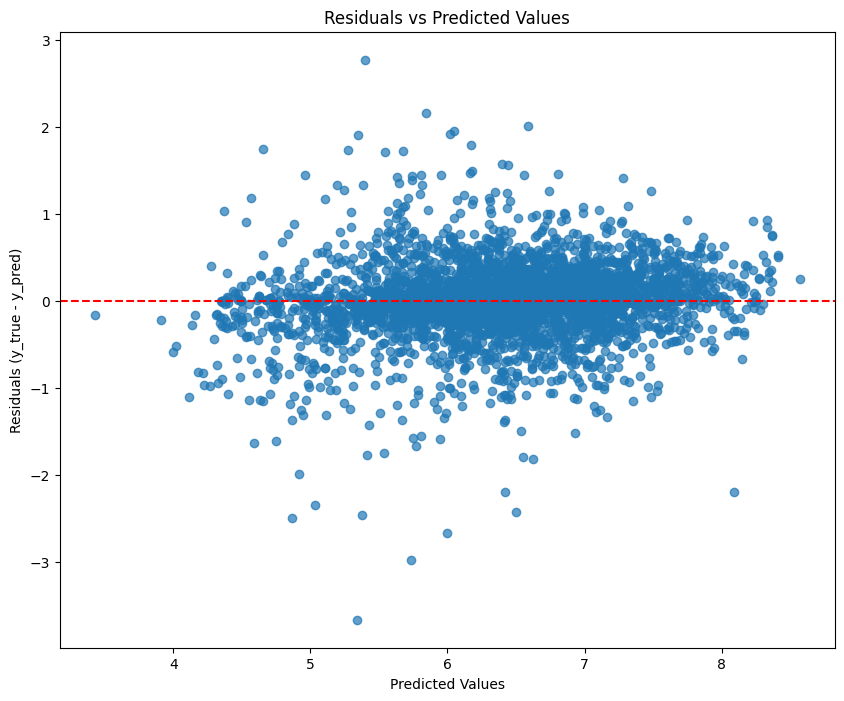

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

residuals = y_test - y_pred


plt.figure(figsize=(10,8))
plt.scatter(y_pred, residuals, alpha=.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residuals vs Predicted Values")
plt.show()

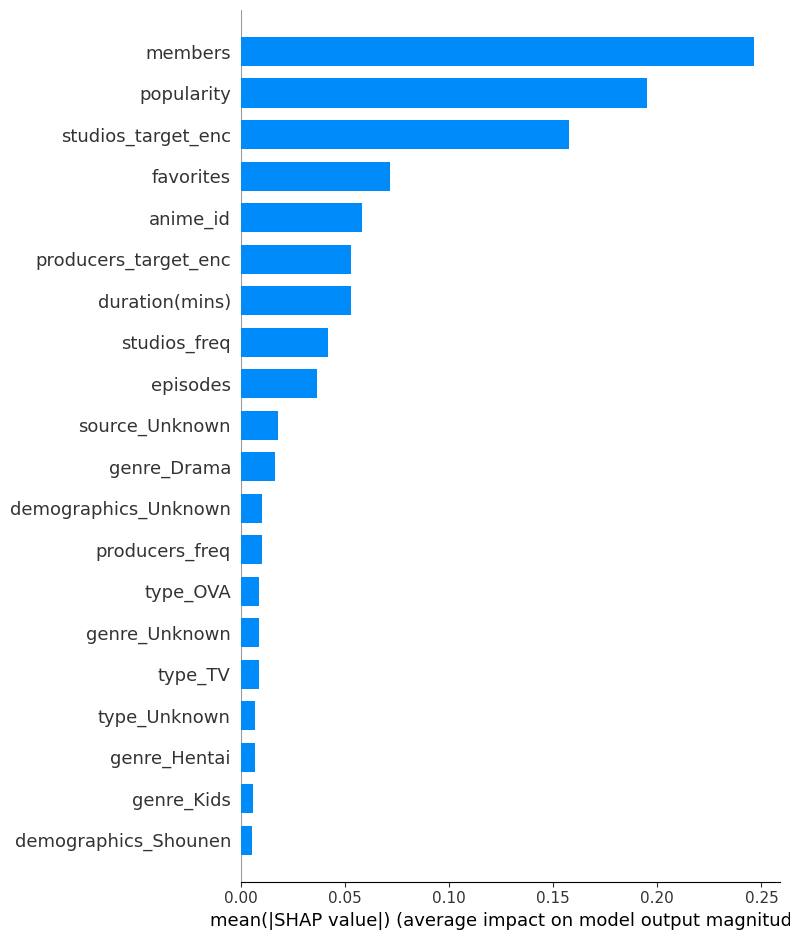

In [5]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test, plot_type="bar")
